In [2]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 22.0 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.0/91.0 kB 4.5 MB/s eta 0:00:00


# Fine-tune YOLOv11 on Sports Image Dataset

Dataset: Sports_100_image_dataset

## 1. Importing Libraries

In [3]:
import os
import math
import glob
import shutil
from pathlib import Path

import cv2
import pandas as pd
import matplotlib.pyplot as plt
import torch
from ultralytics import YOLO

device = 0 if torch.cuda.is_available() else "cpu"

print("torch :", torch.__version__)
print("device:", device)

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
torch : 2.10.0+cu128
device: 0


## 2. Dataset Path and Parameters

In [9]:
DATASET = "/kaggle/input/datasets/gpiosenka/sports-classification"

train_dir = os.path.join(DATASET, "train")
valid_dir = os.path.join(DATASET, "valid")
test_dir  = os.path.join(DATASET, "test")

MODEL_NAME       = "yolo11n-cls.pt"
EPOCHS           = 10
IMG_SIZE         = 224
BATCH            = 32

USE_SUBSET       = False
N_CLASSES        = 100
IMAGES_PER_CLASS = 200

NUM_TEST_IMAGES  = 100
SHOW_IMAGES      = 12

print("Dataset :", DATASET)
print("Exists  :", os.path.exists(DATASET))

Dataset : /kaggle/input/datasets/gpiosenka/sports-classification
Exists  : True


## 3. Loading and Checking the Dataset

In [10]:
classes = sorted([d for d in os.listdir(train_dir)
                  if os.path.isdir(os.path.join(train_dir, d))])

print("Total classes:", len(classes))
print("First 10     :", classes[:10])
print("Last 5       :", classes[-5:])
print()

for name, path in [("train", train_dir), ("valid", valid_dir), ("test", test_dir)]:
    total = 0
    for c in classes:
        folder = os.path.join(path, c)
        if os.path.isdir(folder):
            total = total + len(os.listdir(folder))
    print(f"{name:6s}:", total, "images")

print()
print("Sample classes with image counts (train):")
for c in classes[:5]:
    n = len(os.listdir(os.path.join(train_dir, c)))
    print(f"  {c:25s}: {n} images")

Total classes: 100
First 10     : ['air hockey', 'ampute football', 'archery', 'arm wrestling', 'axe throwing', 'balance beam', 'barell racing', 'baseball', 'basketball', 'baton twirling']
Last 5       : ['water polo', 'weightlifting', 'wheelchair basketball', 'wheelchair racing', 'wingsuit flying']

train : 13493 images
valid : 500 images
test  : 500 images

Sample classes with image counts (train):
  air hockey               : 112 images
  ampute football          : 112 images
  archery                  : 132 images
  arm wrestling            : 99 images
  axe throwing             : 113 images


## 4. Reading sports.csv

In [11]:
csv_file = os.path.join(DATASET, "sports.csv")
data_csv = pd.read_csv(csv_file)

print("Shape  :", data_csv.shape)
print("Columns:", list(data_csv.columns))
print()
data_csv.head()

Shape  : (14493, 4)
Columns: ['class id', 'filepaths', 'labels', 'data set']



,class id,filepaths,labels,data set
0,0,train/air hockey/001.jpg,air hockey,train
1,0,train/air hockey/002.jpg,air hockey,train
2,0,train/air hockey/003.jpg,air hockey,train
3,0,train/air hockey/004.jpg,air hockey,train
4,0,train/air hockey/005.jpg,air hockey,train


## 5. Loading Pre-trained Mode

In [12]:
model = YOLO(MODEL_NAME)

print("Model         :", MODEL_NAME)
print("Task          :", model.task)
print("Pretrained on :", len(model.names), "classes")
print()
print("Final layer before fine-tuning:")
print(model.model.model[-1])

Model         : yolo11n-cls.pt
Task          : classify
Pretrained on : 1000 classes

Final layer before fine-tuning:
Classify(
  (conv): Conv(
    (conv): Conv2d(256, 1280, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(1280, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (act): SiLU(inplace=True)
  )
  (pool): AdaptiveAvgPool2d(output_size=1)
  (drop): Dropout(p=0.0, inplace=True)
  (linear): Linear(in_features=1280, out_features=1000, bias=True)
)


## 6. Fine tunning

In [13]:
results = model.train(
    data=DATASET,
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH,
    device=device,
    workers=4,
    name="sports_cls",
    exist_ok=True,
    seed=42,
    patience=5,
)

SAVE_DIR = Path(results.save_dir)
BEST_MODEL = SAVE_DIR / "weights" / "best.pt"

print()
print("Run folder  :", SAVE_DIR)
print("Best weights:", BEST_MODEL)

Ultralytics 8.4.163 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/input/datasets/gpiosenka/sports-classification, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=sports_cls, nbs=64

/usr/local/lib/python3.12/dist-packages/ray/train/_internal/session.py:676: UserWarning: `get_trial_id` is meant to only be called inside a function that is executed by a Tuner or Trainer. Returning `None`.
  warnings.warn(


       2/10     0.518G      2.916         20        224: 100% ━━━━━━━━━━━━ 422/422 7.0it/s 1:000.1sss
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 8/8 64.8it/s 0.1s0.1s
                   all      0.682      0.896

      Epoch    GPU_mem       loss  Instances       Size
       3/10     0.518G       1.63         20        224: 100% ━━━━━━━━━━━━ 422/422 7.1it/s 59.8s0.1ss
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 8/8 62.1it/s 0.1s0.1s
                   all       0.79       0.96

      Epoch    GPU_mem       loss  Instances       Size
       4/10     0.518G      1.104         20        224: 100% ━━━━━━━━━━━━ 422/422 7.1it/s 59.1s0.1ss
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 8/8 67.8it/s 0.1s0.0s
                   all      0.846      0.984

      Epoch    GPU_mem       loss  Instances       Size
       5/10     0.518G     0.8804         20        224: 100% ━━━━━━━━━━━━ 422/422 7.3it/s 58.2s0.1ss
               classes   top

## 7. Validate

In [15]:
best = YOLO(str(BEST_MODEL))

metrics = best.val(data=DATASET, imgsz=IMG_SIZE, device=device)

print("Top-1 accuracy:", round(float(metrics.top1) * 100, 2), "%")
print("Top-5 accuracy:", round(float(metrics.top5) * 100, 2), "%")

Ultralytics 8.4.163 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLO11n-cls summary (fused): 47 layers, 1,654,124 parameters, 0 gradients, 3.2 GFLOPs
train: /kaggle/input/datasets/gpiosenka/sports-classification/train... found 13492 images in 100 classes ✅ 
val: /kaggle/input/datasets/gpiosenka/sports-classification/valid... found 500 images in 100 classes ✅ 
test: /kaggle/input/datasets/gpiosenka/sports-classification/test... found 500 images in 100 classes ✅ 
val: Fast image access ✅ (ping: 5.8±5.0 ms, read: 52.7±12.4 MB/s, size: 26.7 KB)
val: Scanning /kaggle/input/datasets/gpiosenka/sports-classification/valid... 500 images, 0 corrupt: 100% ━━━━━━━━━━━━ 500/500 448.5it/s 1.1s0.1s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/gpiosenka/sports-classification is not writable, cache not saved.
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 32/32 22.3it/s 1.4s0.2s
                   all      0.914      0.992
Speed: 0.1ms preprocess, 0.9ms in

## 8. Predict on Test Images

In [17]:
test_images = sorted(glob.glob(os.path.join(test_dir, "*", "*.jpg")))[:NUM_TEST_IMAGES]
print("Test images:", len(test_images))

preds = best.predict(source=test_images, imgsz=IMG_SIZE, device=device, verbose=False)

rows = []
for r in preds:
    path = r.path
    class_id = r.probs.top1
    conf = float(r.probs.top1conf)

    rows.append({
        "image":        os.path.basename(path),
        "actual":       os.path.basename(os.path.dirname(path)),
        "predicted":    r.names[class_id],
        "confidence_%": round(conf * 100, 2),
    })

df = pd.DataFrame(rows)
df["correct"] = df["actual"] == df["predicted"]
df.index = df.index + 1

print()
print("PREDICTIONS ON TEST IMAGES")
print(df.to_string())
print()
print("Total images :", len(df))
print("Correct      :", df["correct"].sum())
print("Accuracy     :", round(df["correct"].mean() * 100, 2), "%")
print("Avg confidence:", round(df["confidence_%"].mean(), 2), "%")
df

Test images: 100

PREDICTIONS ON TEST IMAGES
     image           actual          predicted  confidence_%  correct
1    1.jpg       air hockey         air hockey         98.30     True
2    2.jpg       air hockey         air hockey         94.03     True
3    3.jpg       air hockey         air hockey         93.17     True
4    4.jpg       air hockey         air hockey         99.53     True
5    5.jpg       air hockey         air hockey         99.34     True
6    1.jpg  ampute football    ampute football         98.80     True
7    2.jpg  ampute football    ampute football         95.41     True
8    3.jpg  ampute football    ampute football         58.93     True
9    4.jpg  ampute football    ampute football         87.25     True
10   5.jpg  ampute football    ampute football         99.42     True
11   1.jpg          archery            archery         99.54     True
12   2.jpg          archery            archery         95.47     True
13   3.jpg          archery            archer

,image,actual,predicted,confidence_%,correct
1,1.jpg,air hockey,air hockey,98.30,True
2,2.jpg,air hockey,air hockey,94.03,True
3,3.jpg,air hockey,air hockey,93.17,True
4,4.jpg,air hockey,air hockey,99.53,True
5,5.jpg,air hockey,air hockey,99.34,True
...,...,...,...,...,...
96,1.jpg,cheerleading,cheerleading,54.09,True
97,2.jpg,cheerleading,football,46.83,False
98,3.jpg,cheerleading,cheerleading,29.23,True
99,4.jpg,cheerleading,cheerleading,39.85,True


## 9. Display Predictions (image grid)

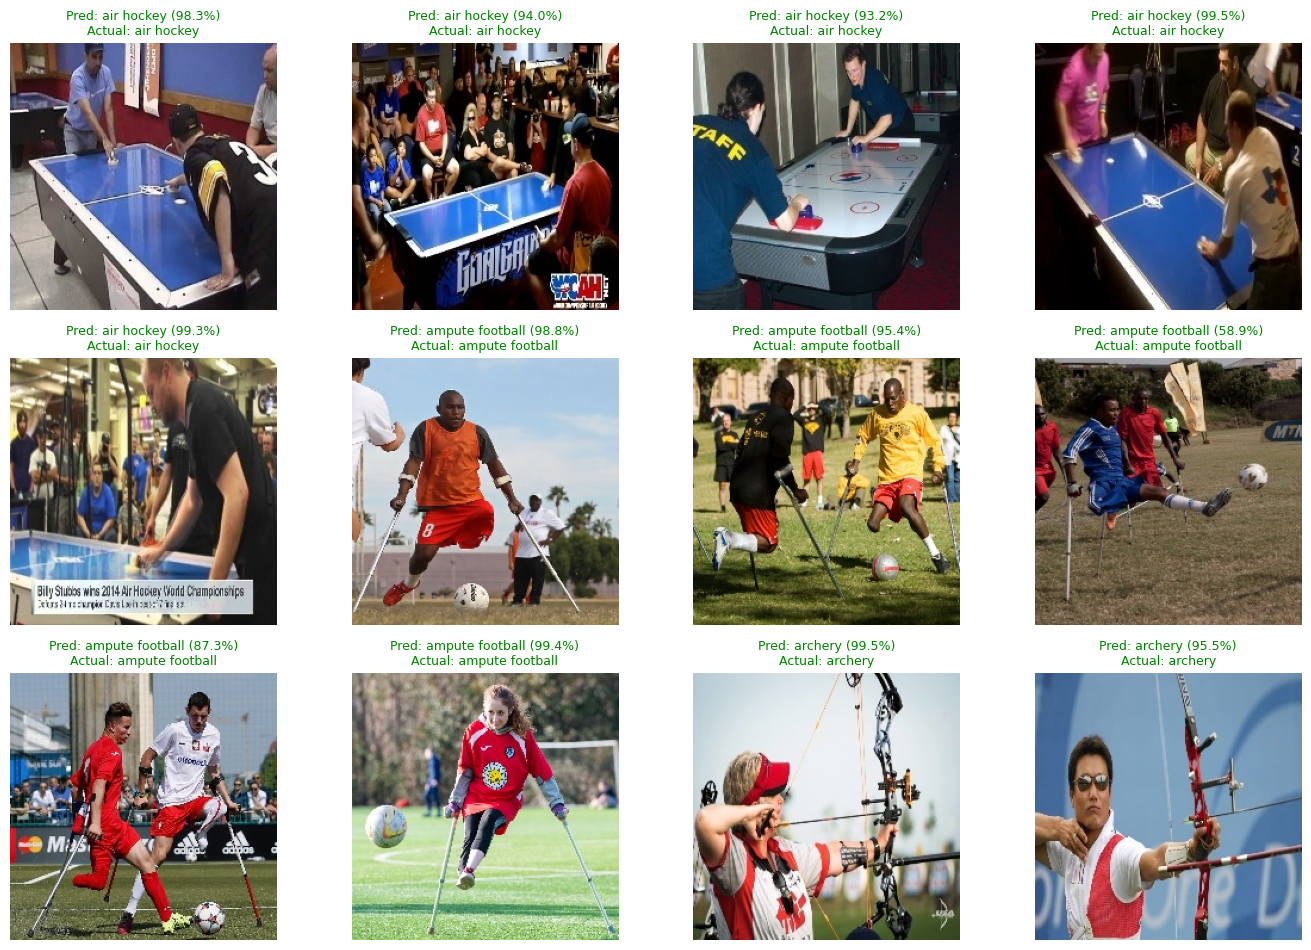

In [18]:
show = min(SHOW_IMAGES, len(preds))
cols = 4
rows_grid = math.ceil(show / cols)

plt.figure(figsize=(14, 3.2 * rows_grid))

for i, r in enumerate(preds[:show]):
    path = r.path
    img = cv2.imread(path)
    if img is None:
        print("Could not read:", path)
        continue

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    predicted = r.names[r.probs.top1]
    conf = float(r.probs.top1conf)
    actual = os.path.basename(os.path.dirname(path))
    ok = (predicted == actual)

    plt.subplot(rows_grid, cols, i + 1)
    plt.imshow(img)
    plt.title(f"Pred: {predicted} ({conf * 100:.1f}%)\nActual: {actual}",
              fontsize=9, color="green" if ok else "red")
    plt.axis("off")

plt.tight_layout()
plt.show()

## 10. Saving Results

In [19]:
df.to_csv("/kaggle/working/sports_predictions.csv", index=False)
shutil.copy(BEST_MODEL, "/kaggle/working/best_sports_model.pt")

print("Saved: sports_predictions.csv")
print("Saved: best_sports_model.pt")

Saved: sports_predictions.csv
Saved: best_sports_model.pt
